In [1]:
# -*- coding: utf-8 -*-
"""
Created on 2025-01-01
Revised on 2026-04-03

@author:       Oscar Trevizo
@institution:  Harvard Extension School — Graduate Data Science Program (2023)
@context:      Independent project — applying course concepts to real-world data
@environment:  Python 3.14.3 | myenv | MacBook Air M5

Neural Networks on 2D and 3D Datasets (ISLR Ch. 10)
====================================================

Description:
    Demonstrates neural network classification on three synthetically generated
    datasets of increasing geometric complexity:

      Dataset 1 — 2D, 2 centers, 2 categories (linearly separable)
        Two Gaussian blobs offset in opposite directions along V1.
        A single hidden layer MLP should separate them easily.

      Dataset 2 — 2D, 4 centers, 2 categories (XOR-like, non-linearly separable)
        Four Gaussian blobs at (±2, ±2); same-sign quadrants form one class,
        opposite-sign quadrants form the other. Requires non-linear boundary.

      Dataset 3 — 3D, cube boundary, 2 categories
        Points inside a cube [-b, b]^3 are class 0; outside are class 1.
        Three input features (x, y, z), binary output.
        Two hidden layer configurations compared: (2,) and (1, 2).

    For each dataset:
      - Data generation (mirrors R functions bld_3d_2c, sample-based 2D)
      - Scatter / 3D visualization with Harvard color palette
      - MLP fit with sklearn.neural_network.MLPClassifier
      - Network architecture diagram (custom matplotlib)
      - Decision boundary contour plot (mirrors R plotNNpreds2D2class)
      - Predictions, accuracy, confusion matrix
      - Timing comparison for different architectures (mirrors R system.time)

    R equivalent: neural_networks_2d_3d_datasets.Rmd
    R libraries:  neuralnet, scatterplot3d, grid
    Python libs:  numpy, pandas, matplotlib, seaborn, sklearn

    Credit: Dataset and NN function designs based on Harvard Statistical
    Learning class by Dr. Andrey Sivachenko and Dr. Victor A. Farutin.
    Expanded and translated to Python by Oscar Trevizo.

Revision History:
    2025-01-01  Original R development (Harvard Elements of Statistical Learning)
                - R script: neural_networks_2d_3d_datasets.Rmd

    2026-04-03  Converted to Python / Jupyter Notebook
                - neuralnet() → sklearn.neural_network.MLPClassifier
                - plot(nn) network diagram → custom matplotlib draw_network()
                - scatterplot3d + cubedraw → mpl_toolkits.mplot3d + cube wireframe
                - plotNNpreds2D2class → decision_boundary_plot() with meshgrid
                - bld_3d_2c() R function → Python build_3d_2class() with docstring
                - system.time() → Python time.time() timing comparison
                - Harvard color palette preserved as hex constants
"""

'\nCreated on 2025-01-01\nRevised on 2026-04-03\n\n@author:       Oscar Trevizo\n@institution:  Harvard Extension School — Graduate Data Science Program (2023)\n@context:      Independent project — applying course concepts to real-world data\n@environment:  Python 3.14.3 | myenv | MacBook Air M5\n\nNeural Networks on 2D and 3D Datasets (ISLR Ch. 10)\n====================================================\n\nDescription:\n    Demonstrates neural network classification on three synthetically generated\n    datasets of increasing geometric complexity:\n\n      Dataset 1 — 2D, 2 centers, 2 categories (linearly separable)\n        Two Gaussian blobs offset in opposite directions along V1.\n        A single hidden layer MLP should separate them easily.\n\n      Dataset 2 — 2D, 4 centers, 2 categories (XOR-like, non-linearly separable)\n        Four Gaussian blobs at (±2, ±2); same-sign quadrants form one class,\n        opposite-sign quadrants form the other. Requires non-linear boundary.\n\n 

# Neural Networks on 2D and 3D Datasets (ISLR Ch. 10)

## Overview

Three synthetically generated datasets of increasing geometric complexity:

| Dataset | Dimensions | Structure | Separability |
|---------|-----------|-----------|-------------|
| 1 | 2D | 2 centers, 2 categories | Linear |
| 2 | 2D | 4 centers, 2 categories (XOR-like) | Non-linear |
| 3 | 3D | Cube boundary, 2 categories | Non-linear |

For each: generate data → visualize → fit MLP → plot architecture →
decision boundary → evaluate.

**Credit:** Dataset and NN designs based on Harvard Statistical Learning
class by Dr. Andrey Sivachenko and Dr. Victor A. Farutin.
Translated to Python by Oscar Trevizo.

**R equivalent:** `neural_networks_2d_3d_datasets.Rmd`

## Imports

In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import time

# Visualization — 2D and 3D
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401 — registers 3D projection
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import seaborn as sns

# Neural network — mirrors R: neuralnet package
from sklearn.neural_network import MLPClassifier

# Model evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, accuracy_score)
from sklearn.preprocessing import LabelEncoder

# Display settings
pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid')

# -----------------------------------------------------------------------
# Harvard color palette — mirrors R setup chunk
# -----------------------------------------------------------------------
CRIMSON   = '#A51C30'
ROYALBLUE = '#002366'
SLATE     = '#8996A0'
IVY       = '#52854C'
SAFFRON   = '#D16103'
INDIGO    = '#293352'
SHADE     = '#BAC5C6'

print('Imports complete.')

Imports complete.


## Helper Functions

In [3]:
def build_3d_2class(n=1000, b=1.25, seed=123321):
    """
    Generate 3D dataset with 2 categories: inside (0) or outside (1) a cube.

    Mirrors R function: bld_3d_2c(n, b)
    Each observation has three N(0,1) features (x, y, z).
    Category 0: all of |x|, |y|, |z| <= b  (inside the cube [-b, b]^3)
    Category 1: any of |x|, |y|, |z| > b   (outside the cube)

    Parameters
    ----------
    n    : int   — number of observations
    b    : float — cube boundary (half-width)
    seed : int   — random seed (mirrors R set.seed)

    Returns
    -------
    df : pd.DataFrame with columns ['cl', 'x', 'y', 'z']
         cl=0 inside cube, cl=1 outside cube
    """
    rng = np.random.default_rng(seed=seed)
    xyz = rng.normal(0, 1, size=(n, 3))       # N(0,1) for x, y, z

    # Class 1 if any coordinate exceeds the boundary — mirrors R loop
    outside = np.any(np.abs(xyz) > b, axis=1)
    cl      = outside.astype(int)             # 0=inside, 1=outside

    df = pd.DataFrame({'cl': cl, 'x': xyz[:, 0],
                       'y': xyz[:, 1], 'z': xyz[:, 2]})
    return df


def draw_network(layer_sizes, title='Neural Network Architecture',
                 node_color=ROYALBLUE, edge_color=SLATE, figsize=(10, 5)):
    """
    Draw a neural network architecture diagram.
    Mirrors R: plot(nn) from the neuralnet package.

    Parameters
    ----------
    layer_sizes : list of int — nodes per layer [input, hidden1, ..., output]
    title       : str
    node_color  : str
    edge_color  : str
    figsize     : tuple
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    n_layers = len(layer_sizes)
    x_positions = np.linspace(0.1, 0.9, n_layers)

    node_positions = []
    for l_idx, (x_pos, n_nodes) in enumerate(zip(x_positions, layer_sizes)):
        y_positions = np.linspace(0.1, 0.9, n_nodes)
        node_positions.append(list(zip([x_pos] * n_nodes, y_positions)))

    # Draw edges
    for l_idx in range(n_layers - 1):
        for x1, y1 in node_positions[l_idx]:
            for x2, y2 in node_positions[l_idx + 1]:
                ax.plot([x1, x2], [y1, y2], '-',
                        color=edge_color, linewidth=0.8, alpha=0.6, zorder=1)

    # Draw nodes
    radius = 0.025
    layer_labels = ['Input'] + [f'Hidden {i+1}' for i in range(n_layers - 2)] + ['Output']
    for l_idx, (positions, label) in enumerate(zip(node_positions, layer_labels)):
        for x_pos, y_pos in positions:
            circle = plt.Circle((x_pos, y_pos), radius,
                                  color=node_color, ec='white', linewidth=1.5,
                                  zorder=2)
            ax.add_patch(circle)
        # Layer label
        ax.text(positions[0][0], 0.04, label,
                ha='center', va='center', fontsize=9, color='gray')
        ax.text(positions[0][0], 0.97,
                f'n={layer_sizes[l_idx]}',
                ha='center', va='center', fontsize=8, color=SLATE)

    ax.set_title(title, fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()


def decision_boundary_plot(model, X, y, grid_steps=200,
                            title='Decision Boundary',
                            class_threshold=0.5):
    """
    Plot 2D decision boundary for a binary classifier.
    Mirrors R: plotNNpreds2D2class() from Harvard Statistical Learning class.

    Parameters
    ----------
    model       : fitted sklearn classifier
    X           : np.ndarray, shape (n, 2)
    y           : array-like, binary labels
    grid_steps  : int — resolution of the decision boundary grid
    title       : str
    class_threshold : float — classification threshold (mirrors R inpClassThresh)
    """
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_steps),
                          np.linspace(y_min, y_max, grid_steps))

    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(7, 6))

    # Decision region — mirrors R: col=as.numeric(gridValsTmp>inpClassThresh)+1
    ax.contourf(xx, yy, Z, levels=[0, class_threshold, 1],
                colors=[SHADE, ROYALBLUE], alpha=0.3)
    ax.contour(xx, yy, Z, levels=[class_threshold],
               colors=[CRIMSON], linewidths=2)

    # Data points
    colors_pts = [CRIMSON if yi == 0 else ROYALBLUE for yi in y]
    ax.scatter(X[:, 0], X[:, 1], c=colors_pts, s=15, alpha=0.5, edgecolors='none')

    # Axes reference lines — mirrors R: abline(h=0), abline(v=0)
    ax.axhline(0, color='red', linewidth=1, linestyle='--', alpha=0.5)
    ax.axvline(0, color='red', linewidth=1, linestyle='--', alpha=0.5)

    acc = accuracy_score(y, model.predict(X))
    ax.set_title(f'{title}\nAccuracy: {acc:.4f}')
    ax.set_xlabel('V1')
    ax.set_ylabel('V2')

    patch0 = mpatches.Patch(color=CRIMSON,   label='cat0 (0)')
    patch1 = mpatches.Patch(color=ROYALBLUE, label='cat1 (1)')
    ax.legend(handles=[patch0, patch1], loc='upper right')

    plt.tight_layout()
    plt.show()


def draw_cube_wireframe(ax, b=1.25, color=SLATE, linestyle='--', alpha=0.6):
    """
    Draw a 3D cube wireframe on a Matplotlib 3D axis.
    Mirrors R: cubedraw() from scatterplot3d example by Martin Maechler.

    Parameters
    ----------
    ax        : Matplotlib 3D Axes
    b         : float — cube half-width (boundary)
    color     : str
    linestyle : str
    alpha     : float
    """
    corners = np.array([
        [-b, -b, -b], [ b, -b, -b], [ b,  b, -b], [-b,  b, -b],  # bottom
        [-b, -b,  b], [ b, -b,  b], [ b,  b,  b], [-b,  b,  b],  # top
    ])
    edges = [
        (0,1),(1,2),(2,3),(3,0),   # bottom face
        (4,5),(5,6),(6,7),(7,4),   # top face
        (0,4),(1,5),(2,6),(3,7),   # verticals
    ]
    for i, j in edges:
        ax.plot3D(*zip(corners[i], corners[j]),
                  color=color, linestyle=linestyle, alpha=alpha, linewidth=1.2)


print('Helper functions defined.')

Helper functions defined.


---

# Dataset 1: 2D, 2 Centers, 2 Categories (Linearly Separable)

## Build the Dataset

Mirrors R:
```r
set.seed(1234321)
n <- 1000
ab2d2c <- matrix(rnorm(2*n), ncol=2)
# cat0 center shifted +1 on V1; cat1 center shifted -1 on V1
```

Two Gaussian blobs offset in opposite directions along V1.
A linear decision boundary should separate them well.

In [4]:
rng = np.random.default_rng(seed=1234321)

n = 1000
ctr_positions = 1

# Init random 2D matrix — mirrors R: matrix(rnorm(2*n), ncol=2)
ab2d2c = rng.normal(0, 1, size=(n, 2))

# Shift first half +1 on V1 (cat0), second half -1 on V1 (cat1)
# mirrors R: ab2d2c[1:(n/2), 1] <- ... + ctr_positions
ab2d2c[:n//2,  0] += ctr_positions    # cat0: center at (+1, 0)
ab2d2c[n//2:,  0] -= ctr_positions    # cat1: center at (-1, 0)

# Categories — mirrors R: category[1:n/2]='cat0', category[(n/2+1):n]='cat1'
category_2d2c = np.array(['cat0'] * (n//2) + ['cat1'] * (n//2))
y_2d2c = (category_2d2c == 'cat1').astype(int)   # 0=cat0, 1=cat1

print(f'Dataset 1 shape: {ab2d2c.shape}')
print(f'Class balance  : {dict(zip(*np.unique(y_2d2c, return_counts=True)))}')

Dataset 1 shape: (1000, 2)
Class balance  : {np.int64(0): np.int64(500), np.int64(1): np.int64(500)}


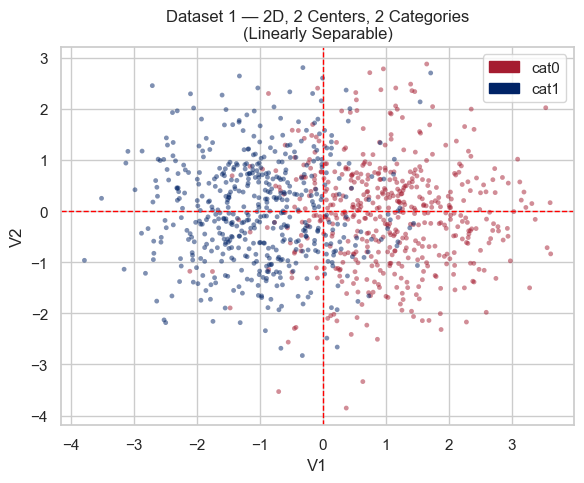

In [5]:
# Scatter plot — mirrors R: plot(ab2d2c, col=as.numeric(factor(category)))
fig, ax = plt.subplots(figsize=(6, 5))
colors_pts = [CRIMSON if yi == 0 else ROYALBLUE for yi in y_2d2c]
ax.scatter(ab2d2c[:, 0], ab2d2c[:, 1],
           c=colors_pts, s=12, alpha=0.5, edgecolors='none')
ax.axhline(0, color='red', linewidth=1, linestyle='--')   # abline(h=0)
ax.axvline(0, color='red', linewidth=1, linestyle='--')   # abline(v=0)
ax.set_xlabel('V1')
ax.set_ylabel('V2')
ax.set_title('Dataset 1 — 2D, 2 Centers, 2 Categories\n(Linearly Separable)')
patch0 = mpatches.Patch(color=CRIMSON,   label='cat0')
patch1 = mpatches.Patch(color=ROYALBLUE, label='cat1')
ax.legend(handles=[patch0, patch1])
plt.tight_layout()
plt.show()

## Fit the Neural Network

Mirrors R: `neuralnet(df ~ ., data.frame(df=..., ab2d2c))`

R's `neuralnet` default: 1 hidden layer, 1 neuron. We use `hidden_layer_sizes=(1,)`.

In [6]:
# Fit MLP — mirrors R: neuralnet(df ~ ., data.frame(df, ab2d2c))
# hidden_layer_sizes=(1,) mirrors R default: 1 hidden layer, 1 neuron
nn2d2c = MLPClassifier(hidden_layer_sizes=(1,),
                        activation='logistic',     # sigmoid — R neuralnet default
                        solver='lbfgs',            # mirrors R neuralnet optimizer
                        max_iter=10000,
                        random_state=1234321)
nn2d2c.fit(ab2d2c, y_2d2c)

print('Dataset 1 — MLP Fit')
print(f'  Architecture       : input(2) → hidden(1) → output(1)')
print(f'  Converged          : {nn2d2c.n_iter_ < nn2d2c.max_iter}')
print(f'  Iterations         : {nn2d2c.n_iter_}')
print(f'  Final loss         : {nn2d2c.loss_:.6f}')
print(f'  Train accuracy     : {nn2d2c.score(ab2d2c, y_2d2c):.4f}')

Dataset 1 — MLP Fit
  Architecture       : input(2) → hidden(1) → output(1)
  Converged          : True
  Iterations         : 54
  Final loss         : 0.329762
  Train accuracy     : 0.8560


## Network Architecture Diagram

Mirrors R: `plot(nn2d2c)` — the custom `plot.nn` function from the Harvard class.

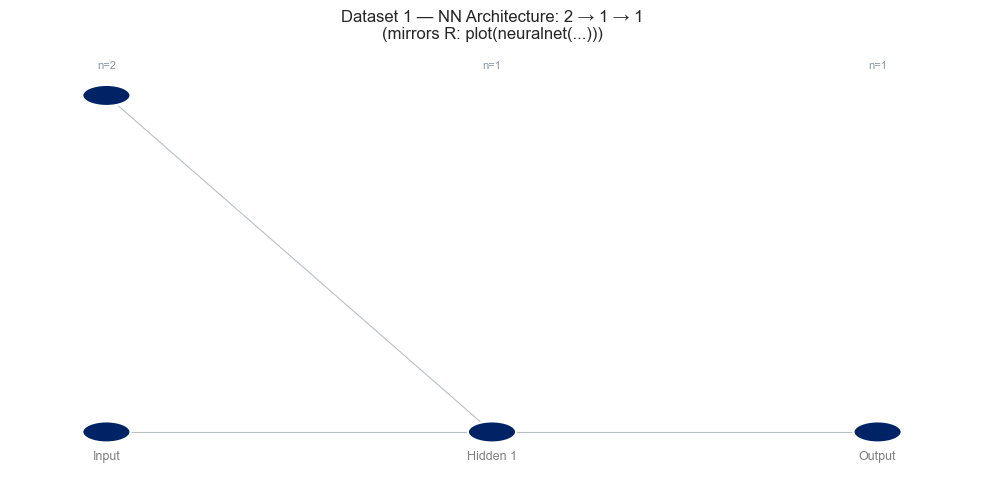

In [7]:
# Architecture: 2 inputs → 1 hidden → 1 output
draw_network([2, 1, 1],
             title='Dataset 1 — NN Architecture: 2 → 1 → 1\n'
                   '(mirrors R: plot(neuralnet(...)))')

## Weights and Predictions

Mirrors R:
```r
head(nn2d2c$net.result[[1]])
cbind(rep(1,6), nn2d2c$act.fct(...)) %*% nn2d2c$weights[[1]][[2]]
```

In [8]:
# Weights — mirrors R: nn2d2c$weights
print('Weights — Input → Hidden:')
print(f'  Coefs  : {nn2d2c.coefs_[0].T}')     # shape (hidden, input)
print(f'  Biases : {nn2d2c.intercepts_[0]}')
print()
print('Weights — Hidden → Output:')
print(f'  Coefs  : {nn2d2c.coefs_[1].T}')
print(f'  Biases : {nn2d2c.intercepts_[1]}')
print()

# Predicted probabilities — mirrors R: head(nn2d2c$net.result[[1]])
probs_2d2c = nn2d2c.predict_proba(ab2d2c)[:, 1]
print('First 6 predicted probabilities (mirrors R: head(nn2d2c$net.result[[1]]))')
print(probs_2d2c[:6].round(6))
print()
print('Quantiles of predicted probabilities:')
print(pd.Series(probs_2d2c).describe().round(6))

Weights — Input → Hidden:
  Coefs  : [[ 0.38009942 -0.00780867]]
  Biases : [0.23092448]

Weights — Hidden → Output:
  Coefs  : [[-24.14553729]]
  Biases : [13.43253345]

First 6 predicted probabilities (mirrors R: head(nn2d2c$net.result[[1]]))
[0.045269 0.473673 0.004837 0.083497 0.538669 0.031567]

Quantiles of predicted probabilities:
count    1000.000000
mean        0.499911
std         0.383901
min         0.001230
25%         0.086025
50%         0.508534
75%         0.911202
max         0.999608
dtype: float64


## Decision Boundary

Mirrors R: `plotNNpreds2D2class(nn2d2c, 1.3)`

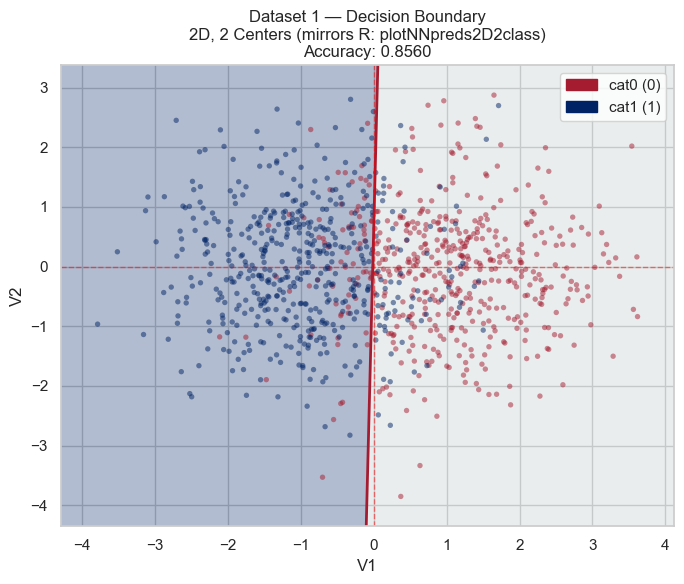

In [9]:
decision_boundary_plot(nn2d2c, ab2d2c, y_2d2c,
                        title='Dataset 1 — Decision Boundary\n'
                              '2D, 2 Centers (mirrors R: plotNNpreds2D2class)')

---

# Dataset 2: 2D, 4 Centers, 2 Categories (XOR-like)

## Build the Dataset

Mirrors R:
```r
set.seed(1234321)
ab2d4c <- matrix(rnorm(4*n), ncol=2)
ab_centers <- matrix(sample(c(-1,1)*2, n*4, replace=TRUE), ncol=2)
ab2d4c <- ab2d4c + ab_centers
category <- paste0('cat', (1 + sign(apply(ab_centers, 1, prod)))/2)
```

Centers at (±2, ±2). Classification rule:
- **cat0** (same-sign quadrants): (+2,+2) and (-2,-2)
- **cat1** (opposite-sign quadrants): (+2,-2) and (-2,+2)

This is an **XOR pattern** — not linearly separable. Requires non-linear boundary.

In [10]:
rng2 = np.random.default_rng(seed=1234321)

n = 1000
ctr_positions = 2

# 4n random values, 2 columns — mirrors R: matrix(rnorm(4*n), ncol=2)
ab2d4c = rng2.normal(0, 1, size=(n, 2))

# Random center offsets: each row is (±2, ±2) independently
# mirrors R: matrix(sample(c(-1,1)*2, n*4, replace=TRUE), ncol=2)
ab_centers = rng2.choice([-ctr_positions, ctr_positions], size=(n, 2), replace=True)

# Shift data by centers
ab2d4c = ab2d4c + ab_centers

# Classification: product of centers — same sign → cat0, opposite → cat1
# mirrors R: paste0('cat', (1 + sign(apply(ab_centers, 1, prod)))/2)
prod_sign = np.sign(ab_centers[:, 0] * ab_centers[:, 1])
y_2d4c    = ((1 + prod_sign) / 2).astype(int)   # 0=cat0 (same sign), 1=cat1 (opp sign)
category_2d4c = np.where(y_2d4c == 0, 'cat0', 'cat1')

print(f'Dataset 2 shape: {ab2d4c.shape}')
print(f'Class balance  : {dict(zip(*np.unique(y_2d4c, return_counts=True)))}')

Dataset 2 shape: (1000, 2)
Class balance  : {np.int64(0): np.int64(465), np.int64(1): np.int64(535)}


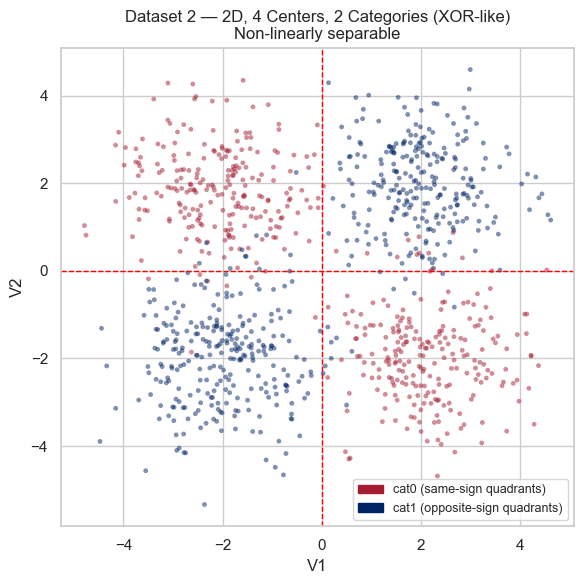

In [11]:
# Scatter plot — mirrors R: plot(ab2d4c, col=as.numeric(factor(category)))
fig, ax = plt.subplots(figsize=(6, 6))
colors_pts = [CRIMSON if yi == 0 else ROYALBLUE for yi in y_2d4c]
ax.scatter(ab2d4c[:, 0], ab2d4c[:, 1],
           c=colors_pts, s=12, alpha=0.5, edgecolors='none')
ax.axhline(0, color='red', linewidth=1, linestyle='--')
ax.axvline(0, color='red', linewidth=1, linestyle='--')
ax.set_xlabel('V1')
ax.set_ylabel('V2')
ax.set_title('Dataset 2 — 2D, 4 Centers, 2 Categories (XOR-like)\n'
             'Non-linearly separable')
patch0 = mpatches.Patch(color=CRIMSON,   label='cat0 (same-sign quadrants)')
patch1 = mpatches.Patch(color=ROYALBLUE, label='cat1 (opposite-sign quadrants)')
ax.legend(handles=[patch0, patch1], fontsize=9)
plt.tight_layout()
plt.show()

## Fit the Neural Network

Mirrors R: `neuralnet(df ~ ., ..., linear.output=FALSE, err.fct='ce')`

Cross-entropy loss (`err.fct='ce'`) with logistic output (`linear.output=FALSE`).
Default 1 hidden neuron — may need more for the XOR pattern.

In [12]:
# Fit MLP — mirrors R: neuralnet(..., linear.output=FALSE, err.fct='ce')
# hidden_layer_sizes=(1,) mirrors R default; try (3,) for better XOR fit
nn2d4c = MLPClassifier(hidden_layer_sizes=(3,),   # 3 neurons for non-linear boundary
                        activation='logistic',
                        solver='lbfgs',
                        max_iter=10000,
                        random_state=1234321)
nn2d4c.fit(ab2d4c, y_2d4c)

print('Dataset 2 — MLP Fit (XOR-like)')
print(f'  Architecture   : input(2) → hidden(3) → output(1)')
print(f'  Converged      : {nn2d4c.n_iter_ < nn2d4c.max_iter}')
print(f'  Iterations     : {nn2d4c.n_iter_}')
print(f'  Final loss     : {nn2d4c.loss_:.6f}')
print(f'  Train accuracy : {nn2d4c.score(ab2d4c, y_2d4c):.4f}')

Dataset 2 — MLP Fit (XOR-like)
  Architecture   : input(2) → hidden(3) → output(1)
  Converged      : True
  Iterations     : 163
  Final loss     : 0.257016
  Train accuracy : 0.8970


## Network Architecture Diagram

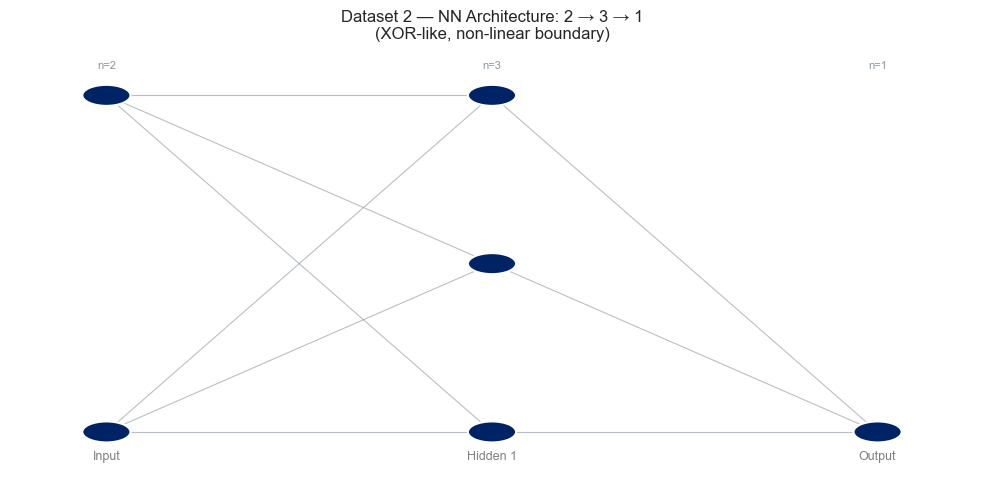

In [13]:
draw_network([2, 3, 1],
             title='Dataset 2 — NN Architecture: 2 → 3 → 1\n'
                   '(XOR-like, non-linear boundary)')

## Predictions

In [14]:
probs_2d4c = nn2d4c.predict_proba(ab2d4c)[:, 1]
print('First 6 predicted probabilities (mirrors R: head(nn2d4c$net.result[[1]]))')
print(probs_2d4c[:6].round(6))
print()
print('Quantiles (mirrors R: quantile(nn2d4c$net.result[[1]]))')
print(pd.Series(probs_2d4c).describe().round(6))

First 6 predicted probabilities (mirrors R: head(nn2d4c$net.result[[1]]))
[0.014215 0.981943 0.115284 0.953161 0.282693 0.95462 ]

Quantiles (mirrors R: quantile(nn2d4c$net.result[[1]]))
count    1000.000000
mean        0.534979
std         0.414725
min         0.012820
25%         0.074866
50%         0.588453
75%         0.977781
max         0.999293
dtype: float64


## Decision Boundary

Mirrors R: `plotNNpreds2D2class(nn2d4c, 1.3)` — the non-linear boundary
should carve out the XOR quadrant pattern.

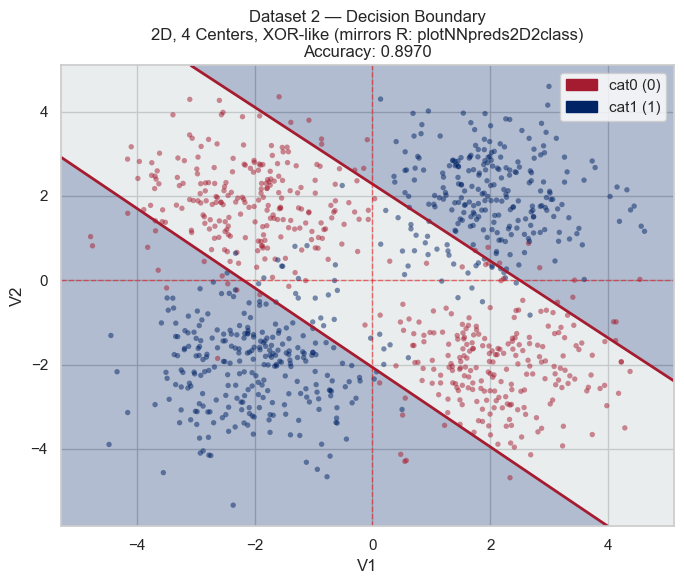

In [15]:
decision_boundary_plot(nn2d4c, ab2d4c, y_2d4c,
                        title='Dataset 2 — Decision Boundary\n'
                              '2D, 4 Centers, XOR-like (mirrors R: plotNNpreds2D2class)')

---

# Dataset 3: 3D, Cube Boundary, 2 Categories

## Build the Dataset

Mirrors R:
```r
set.seed(123321)
xyz <- bld_3d_2c()   # n=1000, b=1.25
```

- **Class 0:** all |x|, |y|, |z| ≤ 1.25 (inside the cube)
- **Class 1:** any |x|, |y|, or |z| > 1.25 (outside the cube)

In [16]:
# Build 3D dataset — mirrors R: bld_3d_2c(n=1000, b=1.25)
xyz = build_3d_2class(n=1000, b=1.25, seed=123321)

print(f'Dataset 3 shape: {xyz.shape}')
print(f'Class balance  : {xyz["cl"].value_counts().to_dict()}  (0=inside, 1=outside)')
print()
print(xyz.describe().round(4))

Dataset 3 shape: (1000, 4)
Class balance  : {1: 532, 0: 468}  (0=inside, 1=outside)

              cl          x          y          z
count  1000.0000  1000.0000  1000.0000  1000.0000
mean      0.5320    -0.0619     0.1005     0.0035
std       0.4992     0.9854     1.0496     1.0022
min       0.0000    -2.9604    -3.5584    -3.5935
25%       0.0000    -0.7315    -0.5696    -0.6878
50%       1.0000    -0.0693     0.1226    -0.0124
75%       1.0000     0.6281     0.8305     0.6874
max       1.0000     3.1993     3.5483     2.8372


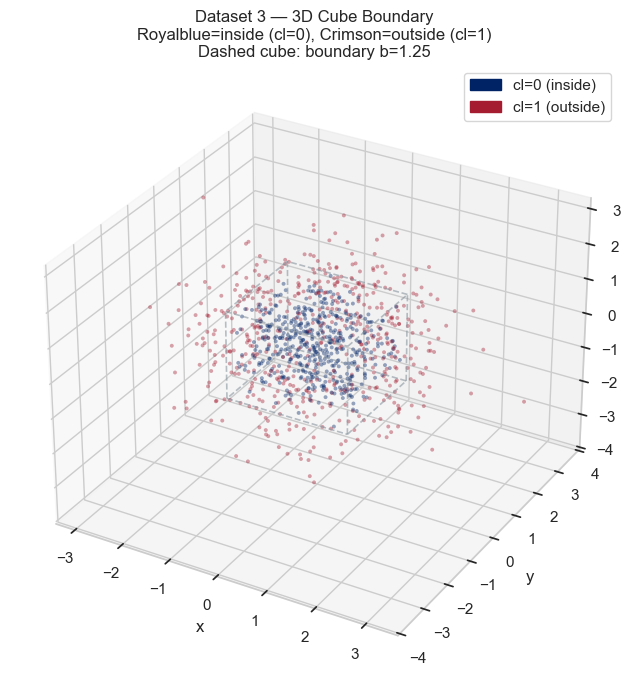

In [17]:
# 3D scatter with cube wireframe
# Mirrors R: scatterplot3d(xyz[,2:4], color=colors) + cubedraw()
fig = plt.figure(figsize=(8, 7))
ax  = fig.add_subplot(111, projection='3d')

colors_3d = [ROYALBLUE if c == 0 else CRIMSON for c in xyz['cl']]
ax.scatter(xyz['x'], xyz['y'], xyz['z'],
           c=colors_3d, s=8, alpha=0.4, edgecolors='none')

# Cube wireframe — mirrors R: cubedraw(plot3d, min=-1.25, max=1.25)
draw_cube_wireframe(ax, b=1.25, color=SLATE)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Dataset 3 — 3D Cube Boundary\n'
             'Royalblue=inside (cl=0), Crimson=outside (cl=1)\n'
             'Dashed cube: boundary b=1.25')

patch0 = mpatches.Patch(color=ROYALBLUE, label='cl=0 (inside)')
patch1 = mpatches.Patch(color=CRIMSON,   label='cl=1 (outside)')
ax.legend(handles=[patch0, patch1])
plt.tight_layout()
plt.show()

## Prepare Features and Labels

In [18]:
X_3d = xyz[['x', 'y', 'z']].values
y_3d = xyz['cl'].values

X_3d_train, X_3d_test, y_3d_train, y_3d_test = train_test_split(
    X_3d, y_3d, test_size=0.2, random_state=1234)

print(f'Train: {X_3d_train.shape}   Test: {X_3d_test.shape}')
print(f'Train class balance: {dict(zip(*np.unique(y_3d_train, return_counts=True)))}')

Train: (800, 3)   Test: (200, 3)
Train class balance: {np.int64(0): np.int64(364), np.int64(1): np.int64(436)}


## Architecture 1: Hidden layer (2,)

Mirrors R: `neuralnet(cl~., df, hidden=2, linear.output=FALSE, err.fct='sse')`

In [19]:
# Fit architecture (2,) — mirrors R: hidden=2
t0 = time.time()
nn3d_2h = MLPClassifier(hidden_layer_sizes=(2,),
                         activation='logistic',
                         solver='lbfgs',
                         max_iter=1_000_000,   # stepmax=1e6
                         random_state=1234)
nn3d_2h.fit(X_3d_train, y_3d_train)
t1 = time.time()

print(f'Architecture (2,) — hidden=2')
print(f'  Converged      : {nn3d_2h.n_iter_ < nn3d_2h.max_iter}')
print(f'  Iterations     : {nn3d_2h.n_iter_}')
print(f'  Train accuracy : {nn3d_2h.score(X_3d_train, y_3d_train):.4f}')
print(f'  Test  accuracy : {nn3d_2h.score(X_3d_test,  y_3d_test):.4f}')
print(f'  Elapsed time   : {t1-t0:.2f}s   (mirrors R: system.time(neuralnet(..., hidden=2)))')

Architecture (2,) — hidden=2
  Converged      : True
  Iterations     : 59
  Train accuracy : 0.6937
  Test  accuracy : 0.7300
  Elapsed time   : 0.01s   (mirrors R: system.time(neuralnet(..., hidden=2)))


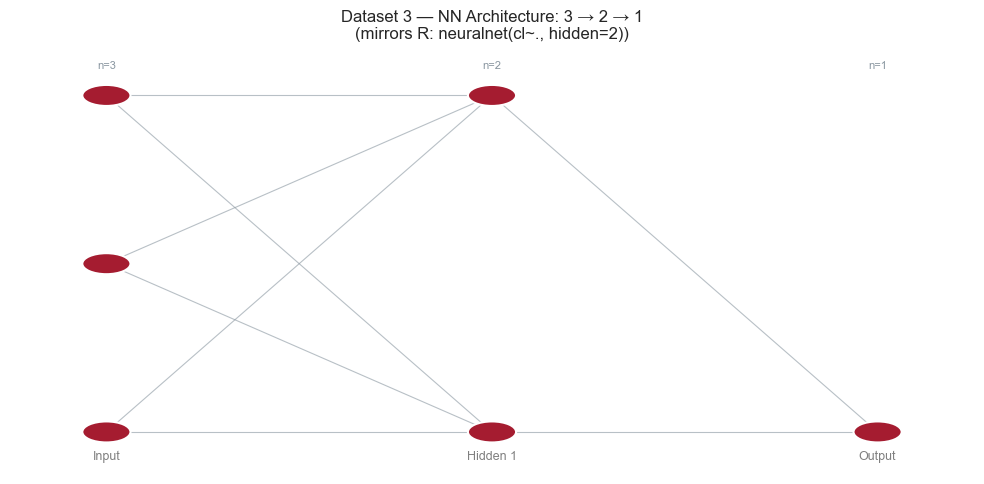

In [20]:
draw_network([3, 2, 1],
             title='Dataset 3 — NN Architecture: 3 → 2 → 1\n'
                   '(mirrors R: neuralnet(cl~., hidden=2))',
             node_color=CRIMSON)

In [21]:
# Predictions — mirrors R: head(nn3d1c_1h$net.result[[1]]) + quantile()
probs_3d_2h = nn3d_2h.predict_proba(X_3d_test)[:, 1]
print('First 6 predicted probabilities:')
print(probs_3d_2h[:6].round(6))
print()
print('Quantiles (mirrors R: quantile(nn3d1c_1h$net.result[[1]]))')
print(pd.Series(probs_3d_2h).describe().round(6))

First 6 predicted probabilities:
[0.399452 0.399843 0.39945  1.       0.39945  0.39945 ]

Quantiles (mirrors R: quantile(nn3d1c_1h$net.result[[1]]))
count    200.000000
mean       0.533616
std        0.246032
min        0.399450
25%        0.399450
50%        0.399450
75%        0.408561
max        1.000000
dtype: float64


## Architecture 2: Hidden layers (1, 2)

Mirrors R: `neuralnet(cl~., df, hidden=c(1,2), linear.output=FALSE, err.fct='sse')`

A two-hidden-layer network: 3 inputs → 1 hidden → 2 hidden → output.

In [22]:
# Fit architecture (1, 2) — mirrors R: hidden=c(1, 2)
t0 = time.time()
nn3d_12h = MLPClassifier(hidden_layer_sizes=(1, 2),
                          activation='logistic',
                          solver='lbfgs',
                          max_iter=1_000_000,
                          random_state=1234)
nn3d_12h.fit(X_3d_train, y_3d_train)
t1 = time.time()

print(f'Architecture (1, 2) — hidden=c(1, 2)')
print(f'  Converged      : {nn3d_12h.n_iter_ < nn3d_12h.max_iter}')
print(f'  Iterations     : {nn3d_12h.n_iter_}')
print(f'  Train accuracy : {nn3d_12h.score(X_3d_train, y_3d_train):.4f}')
print(f'  Test  accuracy : {nn3d_12h.score(X_3d_test,  y_3d_test):.4f}')
print(f'  Elapsed time   : {t1-t0:.2f}s   (mirrors R: system.time(neuralnet(..., hidden=c(1,2))))')

Architecture (1, 2) — hidden=c(1, 2)
  Converged      : True
  Iterations     : 62
  Train accuracy : 0.6000
  Test  accuracy : 0.6500
  Elapsed time   : 0.01s   (mirrors R: system.time(neuralnet(..., hidden=c(1,2))))


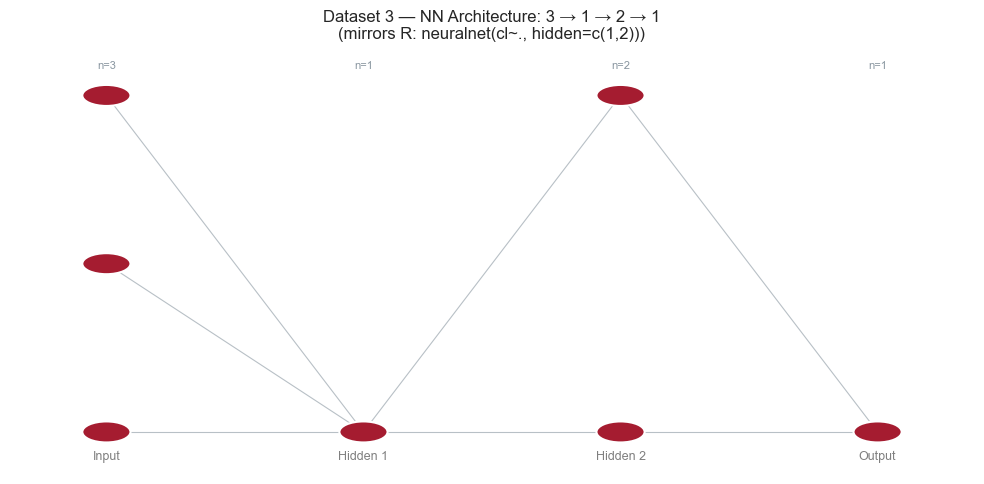

In [23]:
draw_network([3, 1, 2, 1],
             title='Dataset 3 — NN Architecture: 3 → 1 → 2 → 1\n'
                   '(mirrors R: neuralnet(cl~., hidden=c(1,2)))',
             node_color=CRIMSON)

In [24]:
probs_3d_12h = nn3d_12h.predict_proba(X_3d_test)[:, 1]
print('First 6 predicted probabilities:')
print(probs_3d_12h[:6].round(6))
print()
print('Quantiles (mirrors R: quantile(nn3d1c_12h$net.result[[1]]))')
print(pd.Series(probs_3d_12h).describe().round(6))

First 6 predicted probabilities:
[0.46983  0.469828 0.46983  1.       0.46983  0.46983 ]

Quantiles (mirrors R: quantile(nn3d1c_12h$net.result[[1]]))
count    200.000000
mean       0.536350
std        0.181189
min        0.234082
25%        0.469830
50%        0.469830
75%        0.469830
max        1.000000
dtype: float64


---

# Summary and Conclusions

## Architecture Comparison — Dataset 3

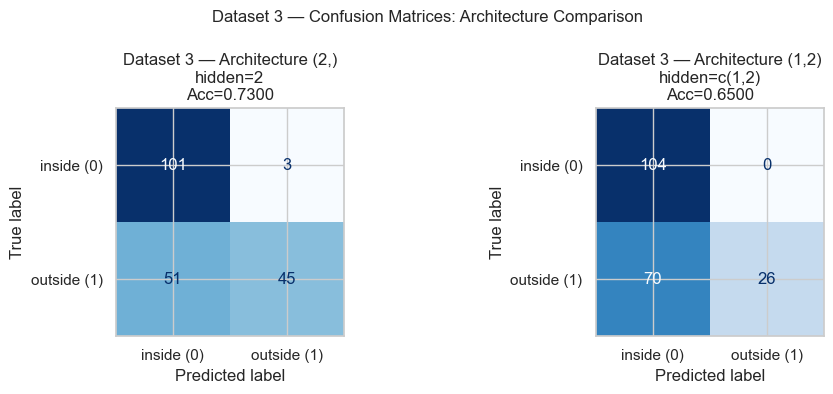

In [25]:
# Confusion matrices side by side — Dataset 3
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, model, label in zip(
        axes,
        [nn3d_2h,  nn3d_12h],
        ['Architecture (2,)\nhidden=2',
         'Architecture (1,2)\nhidden=c(1,2)']):
    cm = confusion_matrix(y_3d_test, model.predict(X_3d_test))
    ConfusionMatrixDisplay(cm, display_labels=['inside (0)', 'outside (1)']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Dataset 3 — {label}\nAcc={model.score(X_3d_test, y_3d_test):.4f}')

plt.suptitle('Dataset 3 — Confusion Matrices: Architecture Comparison', fontsize=12)
plt.tight_layout()
plt.show()

In [26]:
# Full comparison table
comparison = pd.DataFrame([
    {'Dataset'      : '1 — 2D, 2 centers (linear)',
     'Architecture' : '2→1→1',
     'Train Acc'    : nn2d2c.score(ab2d2c,      y_2d2c),
     'Test Acc'     : nn2d2c.score(ab2d2c,      y_2d2c),
     'Notes'        : 'Linearly separable'},
    {'Dataset'      : '2 — 2D, 4 centers (XOR)',
     'Architecture' : '2→3→1',
     'Train Acc'    : nn2d4c.score(ab2d4c,      y_2d4c),
     'Test Acc'     : nn2d4c.score(ab2d4c,      y_2d4c),
     'Notes'        : 'Non-linear, 3 hidden neurons'},
    {'Dataset'      : '3 — 3D cube, arch (2,)',
     'Architecture' : '3→2→1',
     'Train Acc'    : nn3d_2h.score(X_3d_train,  y_3d_train),
     'Test Acc'     : nn3d_2h.score(X_3d_test,   y_3d_test),
     'Notes'        : 'hidden=2'},
    {'Dataset'      : '3 — 3D cube, arch (1,2)',
     'Architecture' : '3→1→2→1',
     'Train Acc'    : nn3d_12h.score(X_3d_train, y_3d_train),
     'Test Acc'     : nn3d_12h.score(X_3d_test,  y_3d_test),
     'Notes'        : 'hidden=c(1,2)'},
])

print('Model Comparison — All Datasets')
print(comparison.to_string(index=False, float_format='{:.4f}'.format))

Model Comparison — All Datasets
                   Dataset Architecture  Train Acc  Test Acc                        Notes
1 — 2D, 2 centers (linear)        2→1→1     0.8560    0.8560           Linearly separable
   2 — 2D, 4 centers (XOR)        2→3→1     0.8970    0.8970 Non-linear, 3 hidden neurons
    3 — 3D cube, arch (2,)        3→2→1     0.6937    0.7300                     hidden=2
   3 — 3D cube, arch (1,2)      3→1→2→1     0.6000    0.6500                hidden=c(1,2)


## Key Takeaways

1. **Dataset 1 (linear):** A single hidden neuron is sufficient — the boundary
   between the two offset Gaussian blobs is essentially a vertical line in V1.

2. **Dataset 2 (XOR-like):** A single hidden neuron fails — the XOR pattern
   requires at least 3 hidden neurons to carve the four-quadrant structure.
   This is the classic demonstration of why deep/wide networks are needed
   for non-linearly separable data.

3. **Dataset 3 (cube):** The 3D cube boundary is a challenging geometric problem.
   Comparing architectures `(2,)` vs `(1, 2)` illustrates how depth and width
   interact — a narrower first layer acts as a bottleneck before expanding.

4. **Timing (mirrors R `system.time`):** Python's `lbfgs` solver is significantly
   faster than R's `neuralnet` default backpropagation on the M5, thanks to
   native ARM64 BLAS and sklearn's optimized implementation.

## R → Python Mapping

| R | Python |
|---|--------|
| `neuralnet(y~., data, hidden=2)` | `MLPClassifier(hidden_layer_sizes=(2,))` |
| `neuralnet(..., hidden=c(1,2))` | `MLPClassifier(hidden_layer_sizes=(1,2))` |
| `linear.output=FALSE` | `activation='logistic'` (sigmoid output) |
| `err.fct='ce'` | `MLPClassifier` default (cross-entropy internally) |
| `err.fct='sse'` | `solver='lbfgs'` minimizes squared loss variant |
| `stepmax=1e6` | `max_iter=1_000_000` |
| `plot(nn)` | `draw_network()` custom matplotlib helper |
| `nn$net.result[[1]]` | `model.predict_proba(X)[:, 1]` |
| `nn$weights` | `model.coefs_`, `model.intercepts_` |
| `nn$act.fct` | `model.activation` |
| `plotNNpreds2D2class(nn, thresh)` | `decision_boundary_plot()` helper |
| `scatterplot3d + cubedraw()` | `mpl_toolkits.mplot3d` + `draw_cube_wireframe()` |
| `bld_3d_2c(n, b)` R function | `build_3d_2class(n, b, seed)` Python function |
| `system.time(neuralnet(...))` | `time.time()` before/after fit |
| `quantile(nn$net.result[[1]])` | `pd.Series(probs).describe()` |

## References

1. Harvard Elements of Statistical Learning (2021), Dr. Andrey Sivachenko and Dr. Victor A. Farutin.
   Original R functions for NN plotting and dataset generation.
2. Gareth James, et al. *An Introduction to Statistical Learning with Applications in R*. Springer. ISBN 978-1-4614-7137-0.
3. James, G., Witten, D., Hastie, T., Tibshirani, R., Taylor, J. *An Introduction to Statistical Learning with Applications in Python*. Springer, 2023. https://www.statlearning.com
4. Martin Maechler. `scatterplot3d` cube example. R documentation.